# 05 — Target candidate set: redundancy и handoff

Fixed-cell transplant уничтожил исходный target candidate, но target подхватывался другой ячейкой. Здесь target представлен как **множество clean candidates**, чьи decoded boxes имеют `IoU >= 0.5` с clean target. Для этого множества строится smooth-max causal path и проверяется sufficiency target-set coordinates.

In [1]:
from pathlib import Path
from dataclasses import replace
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'new_experiments').exists()), None)
if REPO_ROOT is None: raise RuntimeError('Run from inside PatchSuccessResearch')
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

from CandidateRoutingAndAttackPath import load_experiment
from CandidateRoutingAndAttackPath.balanced_target_path import GROUP_ORDER
from CandidateRoutingAndAttackPath.target_candidate_set import (
    TargetCandidateSetConfig, load_target_candidate_set, run_target_candidate_set,
)
pd.set_option('display.max_columns', 100); pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
print('repo:', REPO_ROOT)

repo: /Users/ashentide/PycharmProjects/PatchSuccessResearch


In [2]:
OUTPUT_ROOT = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs'
TRACE_DB = OUTPUT_ROOT / 'candidate_trace_b3c25981c3ad62d5' / 'candidate_tracing.sqlite'
ATTACK_PATH_DB = OUTPUT_ROOT / 'attack_path_0060cc9878ecdb6e' / 'attack_path.sqlite'
MANIFEST_CSV = OUTPUT_ROOT / 'target_instance_all_metrics' / 'balanced_target_selection_5e479438583b28b0' / 'balanced_target_manifest.csv'
RUN_TARGET_CANDIDATE_SET = True
FORCE_TARGET_CANDIDATE_SET = False

for path in [TRACE_DB, ATTACK_PATH_DB, MANIFEST_CSV]:
    if not path.exists(): raise FileNotFoundError(path)
exp, _ = load_experiment(repo_root=REPO_ROOT, prefer_dataset='COCO_people', prefer_device='mps', require_device=False)
set_config = TargetCandidateSetConfig(
    output_dir=str(OUTPUT_ROOT), max_output_gb=8.0, max_examples=None,
    n_steps=16, alpha_batch_size=4, candidate_iou=0.50, candidate_min_score=0.01,
    max_candidates=32, smoothmax_temperature=0.50, top_contributions=2500,
    k_values=(10, 50, 100, 250, 500, 1000), random_repeats=2, forward_batch_size=8,
    detection_conf=0.25, match_iou=0.50, seed=83, progress=True,
)
display(pd.Series({name: getattr(set_config, name) for name in set_config.__slots__}).to_frame('value'))

,value
output_dir,/Users/ashentide/PycharmProjects/PatchSuccessR...
max_output_gb,8.0
max_examples,None
n_steps,16
alpha_batch_size,4
candidate_iou,0.5
candidate_min_score,0.01
max_candidates,32
smoothmax_temperature,0.5
top_contributions,1000


## Дизайн

Для каждого изображения clean target-set фиксируется **до интервенции**: до 32 pre-NMS candidates с clean `IoU >= 0.5`, person-score `>= 0.01`, плюс исходная clean cell. Objective — temperature-controlled smooth maximum их raw person-logits.

Сравниваются при одинаковом числе координат:

- `fixed_top_negative`: прежние координаты для одной clean cell;
- `set_top_negative`: отрицательные causal coordinates smooth-max target-set;
- `set_top_abs`: unsigned target-set control;
- `delta_magnitude`: крупнейшие activation changes;
- `random_delta_matched`: magnitude-matched random, два повтора;
- `patched_full_head`: верхняя граница.

Для каждого post-NMS target match сохраняется его flat index. Поэтому handoff на соседнюю ячейку теперь наблюдается непосредственно: `matched_same_clean_flat`, `matched_in_clean_set`, grid distance и level change.

In [3]:
if RUN_TARGET_CANDIDATE_SET:
    set_result = run_target_candidate_set(
        exp, ATTACK_PATH_DB, TRACE_DB, MANIFEST_CSV, set_config,
        force=FORCE_TARGET_CANDIDATE_SET,
    )
    print('DB:', set_result.db_path)
    print('group summary:', set_result.group_summary_path)
    print('handoff summary:', set_result.handoff_summary_path)
    print('pairwise:', set_result.pairwise_path)
    print('digest:', set_result.digest_path)
else:
    raise RuntimeError('Set RUN_TARGET_CANDIDATE_SET=True or assign an existing set_result')

target candidate set:   0%|          | 0/400 [00:00<?, ?img/s]

DB: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_candidate_set_8e666dcd89791cbd/target_candidate_set.sqlite
group summary: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_candidate_set_8e666dcd89791cbd/candidate_set_group_summary.csv
handoff summary: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_candidate_set_8e666dcd89791cbd/candidate_handoff_summary.csv
pairwise: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_candidate_set_8e666dcd89791cbd/candidate_set_pairwise.csv
digest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_candidate_set_8e666dcd89791cbd/analysis_digest.md


,value
status,complete
n_examples,400
expected_examples,400
n_rows,10400
expected_rows,10400
error_rows,0
mean_candidate_count,10.395
median_relative_completeness_error,0.000532
database,/Users/ashentide/PycharmProjects/PatchSuccessR...
config,{'output_dir': '/Users/ashentide/PycharmProjec...


,n,mean_candidates,median_candidates,mean_exact_delta,median_relative_error
analysis_group,,,,,
visible_target_winner,100,10.66,10.0,-2.020404,0.000498
visible_non_target_winner,100,10.36,10.0,-2.342966,0.000420
hidden_low_conf_match,100,10.37,10.0,-4.912403,0.000520
hidden_no_iou_match,100,10.19,10.0,-5.439454,0.000650


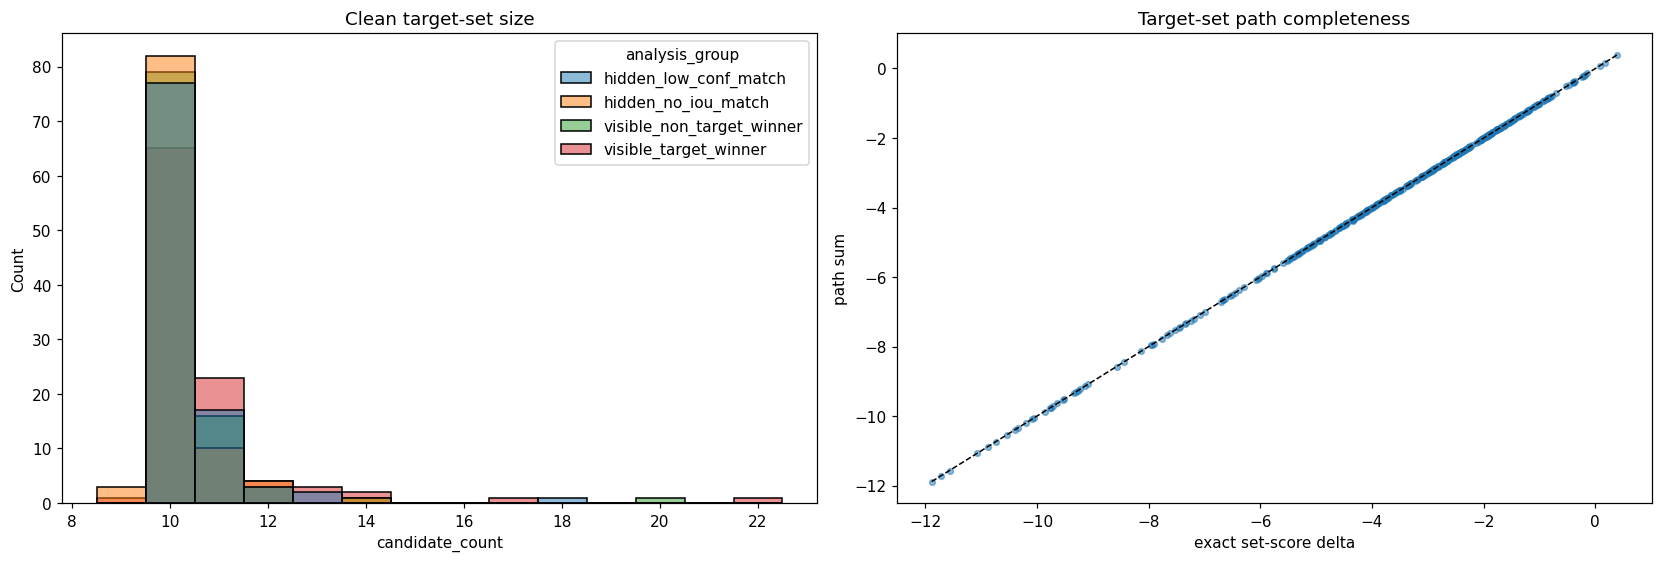

In [4]:
tables = load_target_candidate_set(set_result)
set_examples, set_rows = tables['examples'], tables['results']
display(pd.read_json(set_result.summary_path, typ='series').to_frame('value'))
display(set_examples.groupby('analysis_group').agg(
    n=('example_id', 'size'), mean_candidates=('candidate_count', 'mean'),
    median_candidates=('candidate_count', 'median'),
    mean_exact_delta=('exact_set_delta', 'mean'),
    median_relative_error=('relative_completeness_error', 'median'),
).reindex(GROUP_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
sns.histplot(data=set_examples, x='candidate_count', hue='analysis_group', multiple='layer', discrete=True, ax=axes[0])
axes[0].set_title('Clean target-set size')
axes[1].scatter(set_examples.exact_set_delta, set_examples.path_sum, s=14, alpha=.5)
limits = [min(set_examples.exact_set_delta.min(), set_examples.path_sum.min()), max(set_examples.exact_set_delta.max(), set_examples.path_sum.max())]
axes[1].plot(limits, limits, 'k--', lw=1); axes[1].set(xlabel='exact set-score delta', ylabel='path sum', title='Target-set path completeness')
plt.show()

**Левая панель.** Clean target-set обычно содержит около `10` кандидатов; средние по группам почти совпадают (`10.19–10.66`). Поэтому последующие различия между hidden и visible нельзя объяснить большим числом кандидатов в одной группе. Редкие хвосты до `18–23` показывают, что cap `32` в этом прогоне практически не ограничивает множество.

**Правая панель.** Path sum почти идеально лежит на диагонали exact set-score delta; медианная относительная ошибка всего `0.053%`. Значит, integrated path корректно раскладывает изменение выбранного smooth-max objective. При этом полный патч снижает target-set score заметно сильнее в hidden-группах (`−4.91/−5.44`) против visible (`−2.02/−2.34`), что подтверждает более сильное ensemble-level подавление при успешной атаке.

## Непосредственный candidate handoff

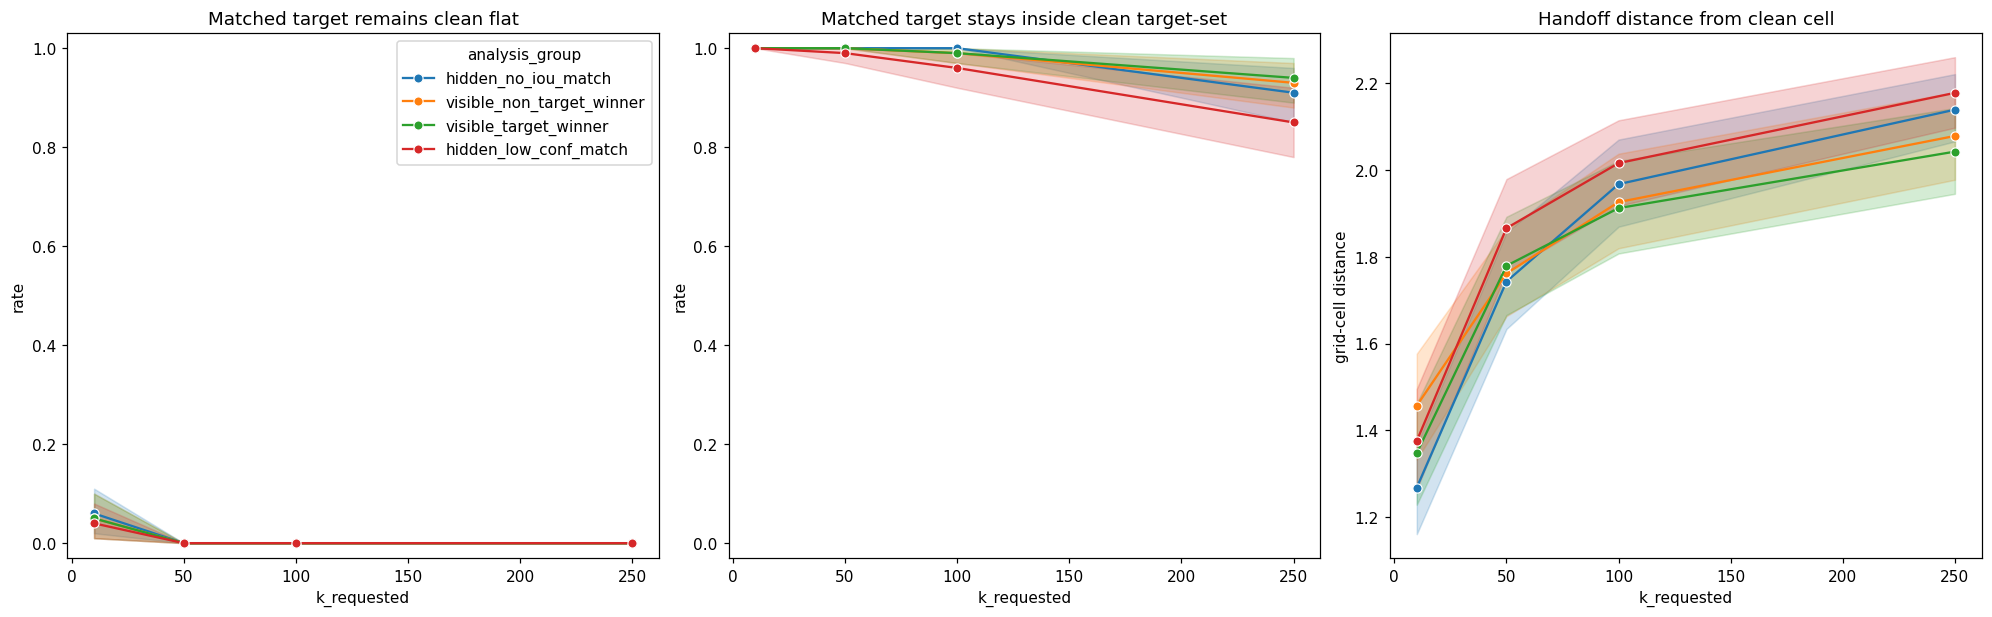

,analysis_group,strategy,k_requested,n,target_hidden_rate,same_clean_flat_rate,in_clean_set_rate,level_changed_rate,mean_grid_distance
5,hidden_low_conf_match,fixed_top_negative,10,100,0.0,0.04,1.00,0.0,1.375838
6,hidden_low_conf_match,fixed_top_negative,50,100,0.0,0.00,0.99,0.0,1.865763
7,hidden_low_conf_match,fixed_top_negative,100,100,0.0,0.00,0.96,0.0,2.015516
8,hidden_low_conf_match,fixed_top_negative,250,100,0.0,0.00,0.85,0.0,2.177298
27,hidden_no_iou_match,fixed_top_negative,10,100,0.0,0.06,1.00,0.0,1.268428
28,hidden_no_iou_match,fixed_top_negative,50,100,0.0,0.00,1.00,0.0,1.742936
29,hidden_no_iou_match,fixed_top_negative,100,100,0.0,0.00,1.00,0.0,1.967079
30,hidden_no_iou_match,fixed_top_negative,250,100,0.0,0.00,0.91,0.0,2.138570
49,visible_non_target_winner,fixed_top_negative,10,100,0.0,0.05,1.00,0.0,1.457089
50,visible_non_target_winner,fixed_top_negative,50,100,0.0,0.00,1.00,0.0,1.761451


In [5]:
unit = set_rows.groupby(
    ['example_id', 'analysis_group', 'match_set', 'strategy', 'k_requested'], as_index=False
).agg(
    target_hidden=('target_hidden', 'mean'), fixed_logit_loss=('fixed_logit_loss', 'mean'),
    target_set_score_loss=('target_set_score_loss', 'mean'), target_conf_loss=('target_conf_loss', 'mean'),
    target_iou_loss=('target_iou_loss', 'mean'), matched_same_clean_flat=('matched_same_clean_flat', 'mean'),
    matched_in_clean_set=('matched_in_clean_set', 'mean'), matched_grid_distance=('matched_grid_distance', 'mean'),
)
fixed = unit[unit.strategy.eq('fixed_top_negative')].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
sns.lineplot(data=fixed, x='k_requested', y='matched_same_clean_flat', hue='analysis_group', marker='o', errorbar=('ci', 95), ax=axes[0])
axes[0].set(title='Matched target remains clean flat', ylabel='rate', ylim=(-.03, 1.03))
sns.lineplot(data=fixed, x='k_requested', y='matched_in_clean_set', hue='analysis_group', marker='o', errorbar=('ci', 95), legend=False, ax=axes[1])
axes[1].set(title='Matched target stays inside clean target-set', ylabel='rate', ylim=(-.03, 1.03))
sns.lineplot(data=fixed, x='k_requested', y='matched_grid_distance', hue='analysis_group', marker='o', errorbar=('ci', 95), legend=False, ax=axes[2])
axes[2].set(title='Handoff distance from clean cell', ylabel='grid-cell distance')
plt.show()
display(pd.read_csv(set_result.handoff_summary_path).query("strategy == 'fixed_top_negative'"))

**Что видно на графике.** После переноса всего `10` strongest fixed-cell coordinates исходная clean-ячейка остаётся match только в `4–6%` случаев, а при `k≥50` — уже в `0%`. Тем не менее target остаётся видимым: до `k=100` новый winner почти всегда (`96–100%`) находится внутри заранее определённого clean target-set. Это прямое наблюдение candidate handoff, а не косвенный вывод из confidence.

С ростом k handoff уходит дальше: среднее расстояние растёт примерно с `1.27–1.46` до `2.04–2.18` grid cells. При `k=250` внутри clean-set остаётся `85–94%` matches, то есть `6–15%` уже переходят к кандидатам вне frozen set. Level-changed rate равен нулю: компенсация происходит локально на том же feature level, а не через переход между масштабами. Кривые четырёх outcome-групп близки, поэтому сама способность к handoff является общей архитектурной redundancy.

## Fixed-cell versus target-set sufficiency

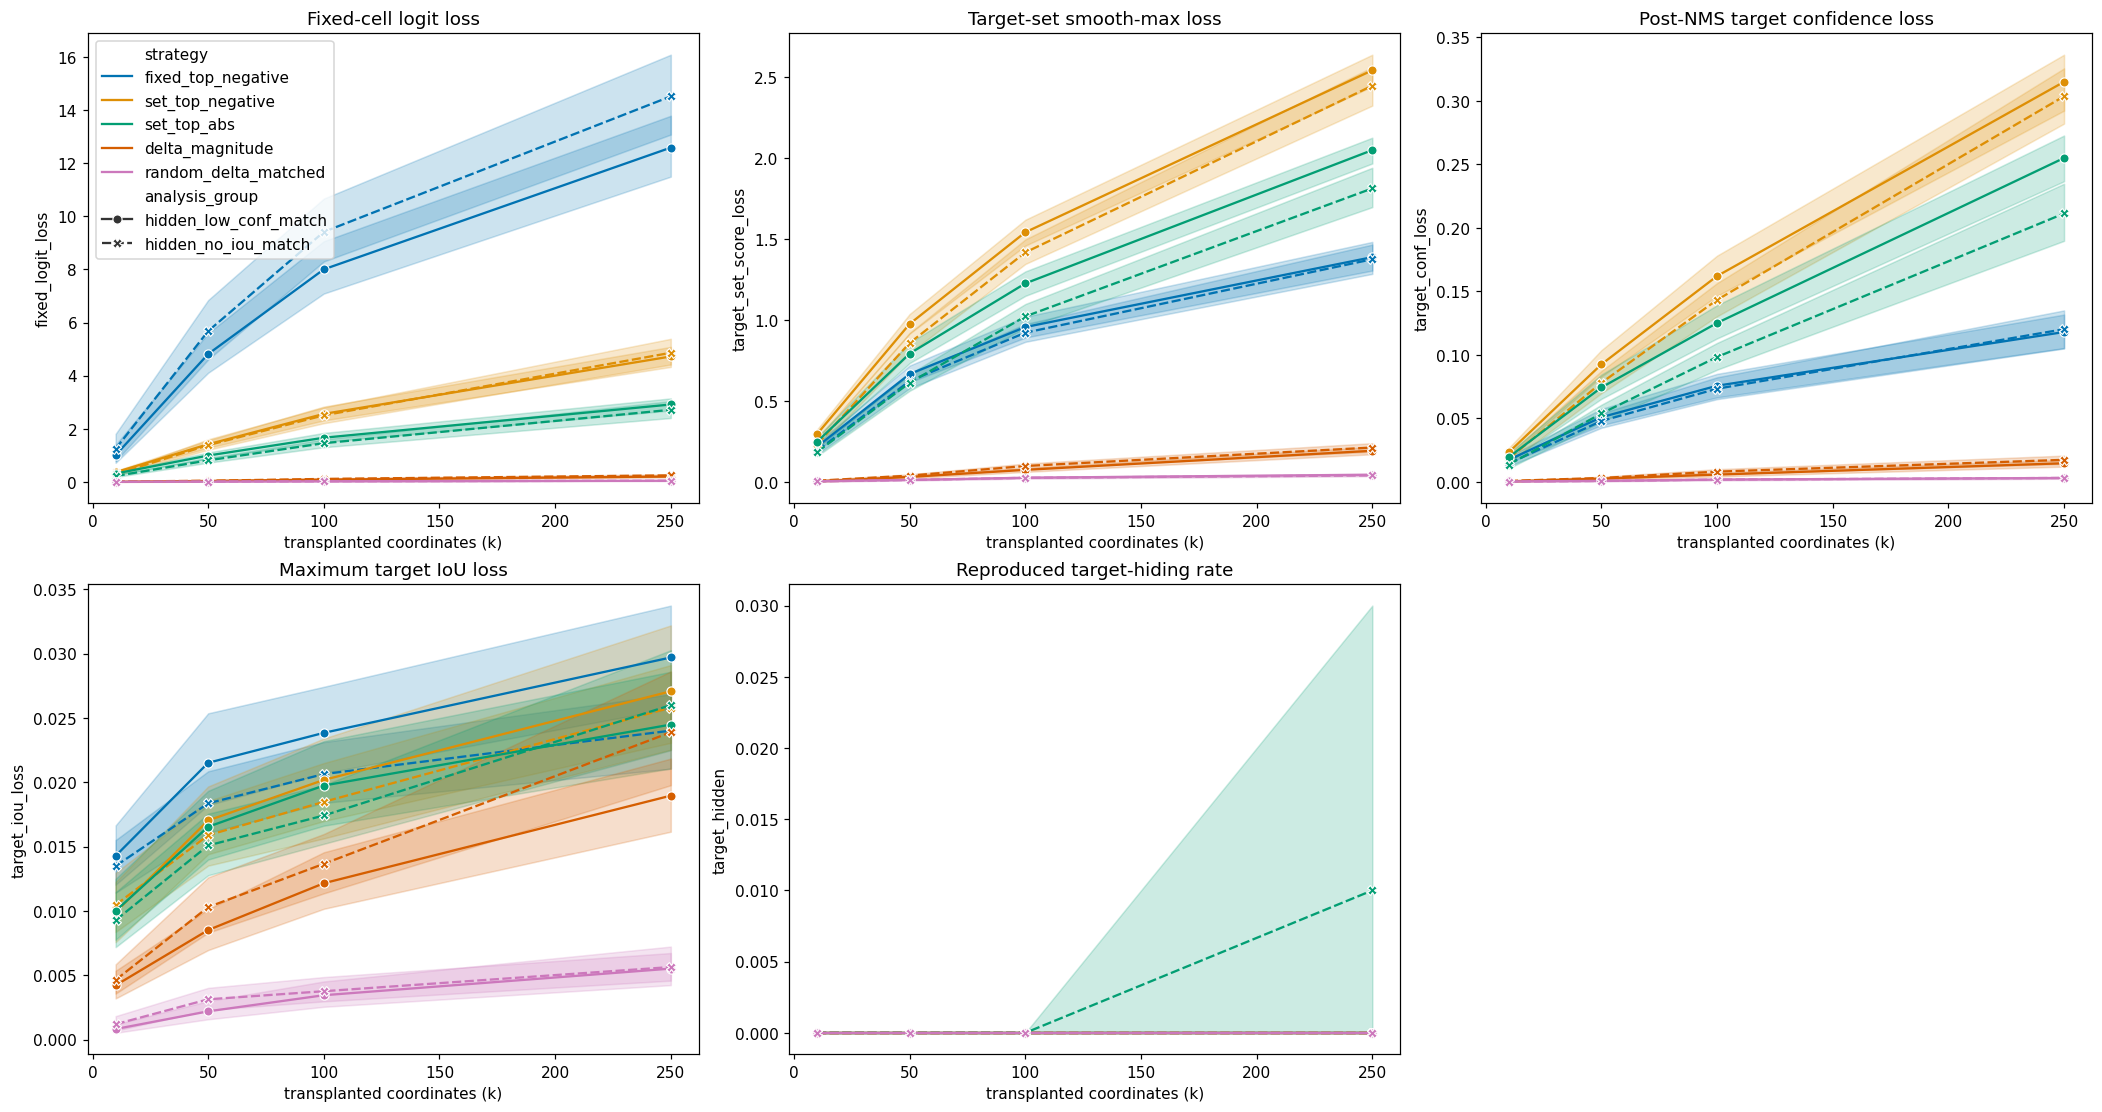

In [6]:
dose = unit[unit.k_requested.gt(0)].copy()
strategy_order = ['fixed_top_negative', 'set_top_negative', 'set_top_abs', 'delta_magnitude', 'random_delta_matched']
hidden_order = ['hidden_low_conf_match', 'hidden_no_iou_match']
palette = dict(zip(strategy_order, sns.color_palette('colorblind', len(strategy_order))))
metrics = [
    ('fixed_logit_loss', 'Fixed-cell logit loss'),
    ('target_set_score_loss', 'Target-set smooth-max loss'),
    ('target_conf_loss', 'Post-NMS target confidence loss'),
    ('target_iou_loss', 'Maximum target IoU loss'),
    ('target_hidden', 'Reproduced target-hiding rate'),
]
fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
for ax, (metric, title) in zip(axes.flat, metrics):
    sns.lineplot(
        data=dose[dose.analysis_group.isin(hidden_order)], x='k_requested', y=metric,
        hue='strategy', style='analysis_group', hue_order=strategy_order, style_order=hidden_order,
        palette=palette, markers=True, dashes=True, errorbar=('ci', 95), ax=ax,
    )
    ax.set(title=title, xlabel='transplanted coordinates (k)')
    if metric != 'fixed_logit_loss' and ax.get_legend() is not None: ax.get_legend().remove()
axes.flat[-1].axis('off'); plt.show()

**Что видно на графике.** `fixed_top_negative` по-прежнему лучше всего уничтожает logit одной clean-ячейки (`12.59/14.51` при `k=250`), но target-set objective почти не следует за ним (`≈1.38`). Новый `set_top_negative`, наоборот, сильнее подавляет весь frozen ensemble (`2.54/2.45`) и даёт существенно больший post-NMS confidence loss (`0.315/0.304`); `set_top_abs` занимает промежуточное положение, а delta/random остаются почти нулевыми. Значит, новый objective действительно выбирает более релевантный ensemble-level mediator.

Но geometry почти не меняется: IoU loss для причинных стратегий остаётся около `0.02–0.03`, и hiding равен `0%` (единичный `1%` у `set_top_abs` no-IoU не образует dose-response). Следовательно, подавление frozen score-ensemble всё ещё недостаточно: target либо переходит за границу множества, либо сохраняется за счёт box/objectness компонентов, которые raw class-logit smooth-max не описывает.

## Endpoint comparison at k=250

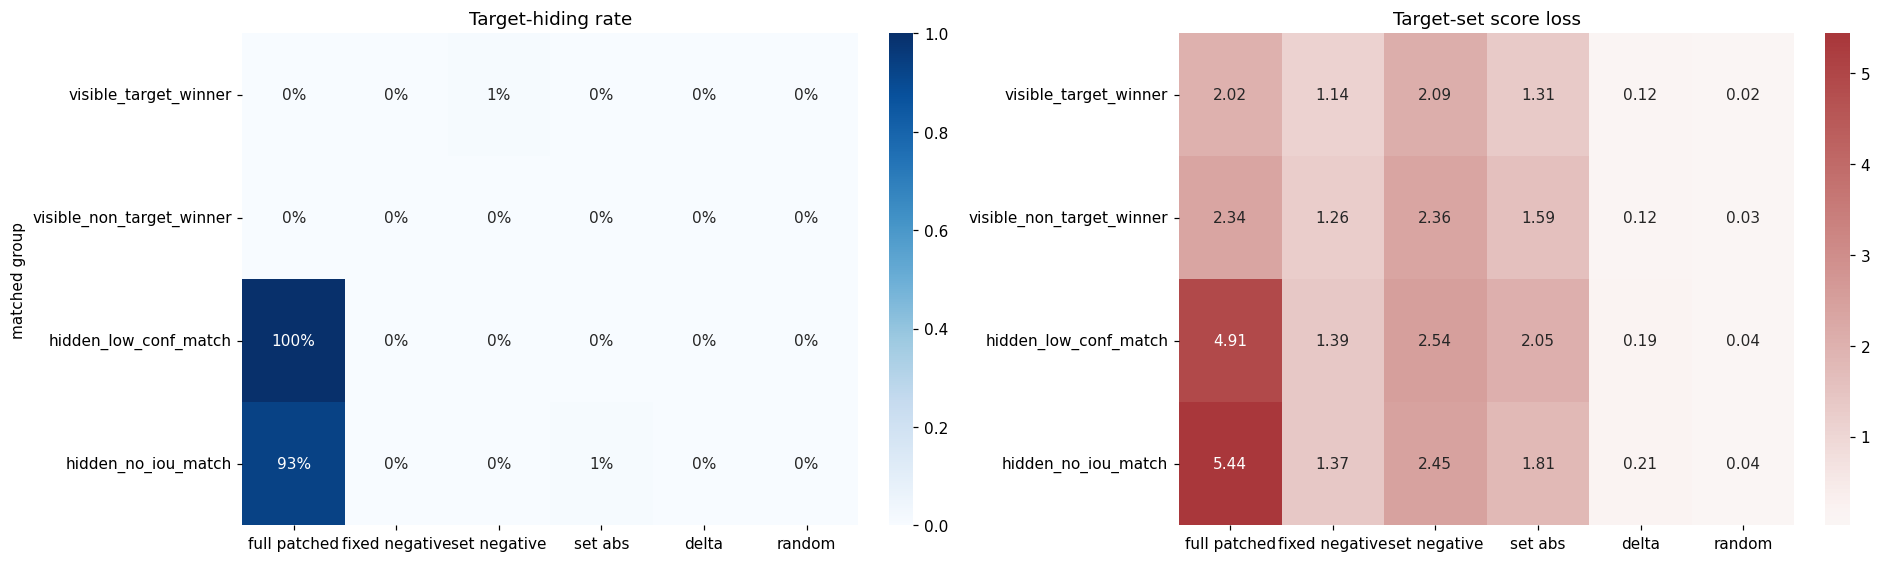

In [7]:
display(Markdown('## Endpoint comparison at k=250'))
endpoint_specs = [
    ('patched_full_head', -1, 'full patched'), ('fixed_top_negative', 250, 'fixed negative'),
    ('set_top_negative', 250, 'set negative'), ('set_top_abs', 250, 'set abs'),
    ('delta_magnitude', 250, 'delta'), ('random_delta_matched', 250, 'random'),
]
parts = []
for strategy, k, label in endpoint_specs:
    part = unit[unit.strategy.eq(strategy) & unit.k_requested.eq(k)].copy(); part['variant'] = label; parts.append(part)
endpoint_data = pd.concat(parts, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)
hidden_table = endpoint_data.pivot_table(index='analysis_group', columns='variant', values='target_hidden', aggfunc='mean').reindex(index=GROUP_ORDER, columns=[x[2] for x in endpoint_specs])
sns.heatmap(hidden_table, annot=True, fmt='.0%', vmin=0, vmax=1, cmap='Blues', ax=axes[0])
axes[0].set(title='Target-hiding rate', xlabel='', ylabel='matched group')
set_loss_table = endpoint_data.pivot_table(index='analysis_group', columns='variant', values='target_set_score_loss', aggfunc='mean').reindex(index=GROUP_ORDER, columns=[x[2] for x in endpoint_specs])
sns.heatmap(set_loss_table, annot=True, fmt='.2f', center=0, cmap='vlag', ax=axes[1])
axes[1].set(title='Target-set score loss', xlabel='', ylabel='')
plt.show()

**Левая панель.** Полный patched Detect-input скрывает low-confidence target в `100%` и no-IoU target в `93%` случаев. Все selective варианты при `k=250` остаются на `0%`, кроме единичного `1%` у `set_abs` в no-IoU и `set_negative` в visible-target — это скорее шум/редкий boundary case, а не воспроизведение механизма.

**Правая панель.** `set_top_negative` воспроизводит около половины full-patch target-set loss в hidden-группах (`2.54` из `4.91`, `2.45` из `5.44`), но примерно весь loss в visible-группах (`2.09` против `2.02`, `2.36` против `2.34`) — и всё равно не скрывает target. Поэтому один scalar set-score не является достаточным endpoint. Успешные атаки дополнительно содержат более длинный распределённый хвост и/или геометрический компонент, отсутствующий в top-250 class-selected transplant.

In [8]:
pairwise = pd.read_csv(set_result.pairwise_path)
display(Markdown('## Paired set-negative advantage'))
display(pairwise[
    pairwise.analysis_group.isin(hidden_order) & pairwise.k_requested.eq(250)
].sort_values(['analysis_group', 'metric', 'control']))

## Paired set-negative advantage

,analysis_group,k_requested,control,metric,n,set_mean,control_mean,mean_difference,p_value,p_holm
249,hidden_low_conf_match,250,delta_magnitude,target_conf_loss,100,0.315045,0.014601,0.300444,3.896560e-18,9.975193e-16
241,hidden_low_conf_match,250,fixed_top_negative,target_conf_loss,100,0.315045,0.117970,0.197075,8.519073e-18,1.499357e-15
253,hidden_low_conf_match,250,random_delta_matched,target_conf_loss,100,0.315045,0.003028,0.312018,3.896560e-18,9.975193e-16
245,hidden_low_conf_match,250,set_top_abs,target_conf_loss,100,0.315045,0.255058,0.059987,7.691675e-10,8.845426e-08
251,hidden_low_conf_match,250,delta_magnitude,target_hidden,100,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
243,hidden_low_conf_match,250,fixed_top_negative,target_hidden,100,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
255,hidden_low_conf_match,250,random_delta_matched,target_hidden,100,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
247,hidden_low_conf_match,250,set_top_abs,target_hidden,100,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
250,hidden_low_conf_match,250,delta_magnitude,target_iou_loss,100,0.027074,0.018961,0.008114,1.193363e-04,1.157562e-02
242,hidden_low_conf_match,250,fixed_top_negative,target_iou_loss,100,0.027074,0.029699,-0.002625,1.292211e-02,1.000000e+00


## Follow-up: длинный хвост и расширение candidate closure

Первый прогон показал, что `k=250` воспроизводит лишь часть full-patch set loss на скрытых целях, а после интервенции match часто выходит за frozen clean set. Поэтому здесь тем же экспериментом проверяются две минимальные модификации:

1. **Длинный хвост:** основной прогон выше теперь продолжается до `k=500` и `k=1000`. Смотрите на `actual_k`: если отрицательных координат среди сохранённых top contributions меньше запрошенного `k`, plateau нельзя интерпретировать как исчерпание всех отрицательных вкладов.
2. **Candidate closure:** clean target-set расширяется по IoU (`0.50 → 0.30 → 0.10`) и по допустимому размеру (`32 → 64 → 128`). Так мы проверяем, можно ли заранее включить соседних кандидатов, которым передаётся target.

Каждая конфигурация получает отдельную hash-папку и возобновляемую SQLite-базу. Общий storage budget остаётся 8 ГБ для всей папки `outputs`, то есть ниже ограничения исследования в 20 ГБ. Разделение classification и box-regression ветвей здесь не выполняется: текущая интервенция стоит до разветвления YOLO Detect head, поэтому branch-specific transplant требует отдельной точки перехвата, а не изменения конфигурации.

In [ ]:
RUN_CANDIDATE_CLOSURE_SWEEP = True
FORCE_CANDIDATE_CLOSURE_SWEEP = False
FOLLOWUP_K = (250, 500, 1000)

closure_configs = {
    'IoU ≥ 0.30': replace(
        set_config, candidate_iou=0.30, max_candidates=64,
        k_values=FOLLOWUP_K,
    ),
    'IoU ≥ 0.10': replace(
        set_config, candidate_iou=0.10, max_candidates=128,
        k_values=FOLLOWUP_K,
    ),
}
display(pd.DataFrame({
    label: {
        'candidate_iou': cfg.candidate_iou, 'max_candidates': cfg.max_candidates,
        'top_contributions': cfg.top_contributions, 'k_values': cfg.k_values,
        'max_output_gb': cfg.max_output_gb,
    }
    for label, cfg in {'IoU ≥ 0.50': set_config, **closure_configs}.items()
}).T)

In [ ]:
closure_results = {'IoU ≥ 0.50': set_result}
if RUN_CANDIDATE_CLOSURE_SWEEP:
    for label, config in closure_configs.items():
        print(f'\n=== {label} ===')
        closure_results[label] = run_target_candidate_set(
            exp, ATTACK_PATH_DB, TRACE_DB, MANIFEST_CSV, config,
            force=FORCE_CANDIDATE_CLOSURE_SWEEP,
        )
        print('DB:', closure_results[label].db_path)
        print('digest:', closure_results[label].digest_path)
else:
    print('Closure sweep skipped; only IoU ≥ 0.50 will be analysed.')

In [ ]:
followup_units = []
followup_examples = []
followup_status = []
for closure, result in closure_results.items():
    tables = load_target_candidate_set(result)
    examples_i, rows_i = tables['examples'].copy(), tables['results'].copy()
    examples_i['closure'] = closure
    followup_examples.append(examples_i)
    unit_i = rows_i.groupby(
        ['example_id', 'analysis_group', 'strategy', 'k_requested'], as_index=False
    ).agg(
        actual_k=('actual_k', 'mean'), target_hidden=('target_hidden', 'mean'),
        target_set_score_loss=('target_set_score_loss', 'mean'),
        target_conf_loss=('target_conf_loss', 'mean'), target_iou_loss=('target_iou_loss', 'mean'),
        matched_in_clean_set=('matched_in_clean_set', 'mean'),
        matched_grid_distance=('matched_grid_distance', 'mean'),
    )
    unit_i['closure'] = closure
    full_i = unit_i[unit_i.strategy.eq('patched_full_head')][
        ['example_id', 'target_set_score_loss']
    ].rename(columns={'target_set_score_loss': 'full_set_score_loss'})
    unit_i = unit_i.merge(full_i, on='example_id', how='left', validate='many_to_one')
    unit_i['set_loss_fraction_full'] = (
        unit_i.target_set_score_loss / unit_i.full_set_score_loss.replace(0, np.nan)
    )
    followup_units.append(unit_i)
    summary_i = pd.read_json(result.summary_path, typ='series')
    followup_status.append({
        'closure': closure, 'status': summary_i['status'], 'examples': summary_i['n_examples'],
        'rows': summary_i['n_rows'], 'errors': summary_i['error_rows'],
        'mean_candidates': summary_i['mean_candidate_count'],
        'median_relative_error': summary_i['median_relative_completeness_error'],
        'run_dir': str(result.run_dir),
    })
followup_unit = pd.concat(followup_units, ignore_index=True)
followup_example = pd.concat(followup_examples, ignore_index=True)
display(pd.DataFrame(followup_status))

In [ ]:
followup = followup_unit[
    followup_unit.strategy.eq('set_top_negative')
    & followup_unit.analysis_group.isin(hidden_order)
    & followup_unit.k_requested.isin(FOLLOWUP_K)
].copy()
closure_order = ['IoU ≥ 0.50', 'IoU ≥ 0.30', 'IoU ≥ 0.10']
closure_order = [value for value in closure_order if value in followup.closure.unique()]
fig, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
plot_specs = [
    ('target_hidden', 'Reproduced target-hiding rate', (-.03, 1.03)),
    ('set_loss_fraction_full', 'Fraction of full-patch set loss', None),
    ('target_conf_loss', 'Post-NMS confidence loss', None),
    ('target_iou_loss', 'Maximum target IoU loss', None),
    ('matched_in_clean_set', 'Matched target remains inside this closure', (-.03, 1.03)),
    ('matched_grid_distance', 'Handoff distance from clean cell', None),
]
for ax, (metric, title, ylim) in zip(axes.flat, plot_specs):
    sns.lineplot(
        data=followup, x='k_requested', y=metric, hue='closure', style='analysis_group',
        hue_order=closure_order, style_order=hidden_order, markers=True, dashes=True,
        errorbar=('ci', 95), ax=ax,
    )
    ax.set(title=title, xlabel='transplanted negative coordinates (requested k)', ylim=ylim)
    if ax is not axes.flat[0] and ax.get_legend() is not None: ax.get_legend().remove()
plt.show()

display(Markdown('### Сколько координат реально было transplanted'))
display(followup.groupby(
    ['closure', 'analysis_group', 'k_requested'], observed=True
).actual_k.agg(['mean', 'min', 'max']).round(1))

**Статус интерпретации.** Эта follow-up клетка ещё не запускалась: в сохранённом ноутбуке нет ни графика, ни результатов для `k=500/1000` и расширенных IoU-closures. Поэтому содержательный вывод здесь намеренно не зафиксирован — перенос выводов с `k≤250` был бы выдумкой. После запуска ключевой тест: растёт ли hiding вместе с долей full-patch set loss и уменьшается ли выход match за closure; обязательно сначала проверить таблицу `actual_k`, чтобы plateau не оказался следствием исчерпания сохранённых negative coordinates.

In [ ]:
endpoint_k = max(FOLLOWUP_K)
endpoint = followup[followup.k_requested.eq(endpoint_k)].copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
endpoint_specs = [
    ('target_hidden', 'Target-hiding rate', '.0%', 0, 1, 'Blues'),
    ('set_loss_fraction_full', 'Fraction of full-patch set loss', '.2f', None, None, 'vlag'),
    ('target_conf_loss', 'Post-NMS confidence loss', '.2f', None, None, 'mako'),
    ('target_iou_loss', 'Maximum target IoU loss', '.2f', None, None, 'rocket'),
]
for ax, (metric, title, fmt, vmin, vmax, cmap) in zip(axes.flat, endpoint_specs):
    table = endpoint.pivot_table(
        index='analysis_group', columns='closure', values=metric, aggfunc='mean'
    ).reindex(index=hidden_order, columns=closure_order)
    sns.heatmap(table, annot=True, fmt=fmt, vmin=vmin, vmax=vmax, cmap=cmap, ax=ax)
    ax.set(title=f'{title}, k={endpoint_k}', xlabel='', ylabel='')
plt.show()

**Статус интерпретации.** Endpoint heatmap для `k=1000` ещё не построен, поэтому численного вывода пока нет. После появления output сравнение должно отвечать двум раздельным вопросам: (1) приближается ли set-score/confidence loss к full patch и (2) превращается ли это в hiding/IoU loss. Если первое выполняется без второго, расширение class-based candidate set исчерпано и следующий эксперимент должен разделять classification и box-regression ветви.

## Как принимать решение

1. После fixed-cell transplant match переходит на другую ячейку, но остаётся внутри clean target-set — candidate redundancy подтверждена непосредственно.
2. `set_top_negative` сильнее fixed-cell по set-score/confidence и начинает воспроизводить hiding — недостаточным звеном был именно ensemble альтернативных target candidates.
3. Set-score падает, но target всё равно виден — проверьте follow-up выше. Рост hiding с `k` означает распределённый длинный хвост; рост hiding при снижении candidate IoU означает, что исходный frozen set был слишком узок.
4. Даже при `k=1000` target виден и выходит из расширенного closure — фиксированный clean-set принципиально не замкнут относительно интервенции; нужен adaptive/spatial objective.
5. Confidence приближается к full patch, но IoU loss остаётся мал — следующим отдельным экспериментом надо разделять classification и box-regression ветви Detect head.
6. Set-negative и set-abs одинаковы — знак не добавляет специфичности для ensemble objective.
7. Delta/random сопоставимы с set-negative — causal selection не специфична и target-set hypothesis не подтверждается.

Основной article-level результат возможен, если fixed-cell coordinates окажутся necessary-only, а candidate-set coordinates дадут одновременно necessity и sufficiency при преимуществах над controls.